# Analyse PE samples
Notebook to analyse the PE samples. Starts by reading in the correct config and backend files from the correct sampling directory. Then it unpacks the loglikelihood and we can assess the convergence based on the loglikelihood and the traces of the deviation for each sampled parameter. That should look like gaussian, stationary noise, otherwise the sampler has not converged yet and we need to take more samples. 

The notebook produces some plots showing the results. First two corner plots, one with and and one without the extrisic parameters. Then two plots to determine the convergence: one of the evolution of the estimated variance (=diagonal element of covariance matrix) for each parameter, and one with the Gelman-Rubin criterion for convergence. 

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.size'] = 14

from src.io import param_load
from src.analysis import (
    sampled_params_from_config,
    load_samples,
    load_samples_named,
    plot_log_like,
    cut_samples_autocorr,
    filter_lost_walkers,
    corner_plot,
    plot_sky_position,
    plot_chain_convergence,
    plot_covariance_evolution,
    plot_gelman_rubin,
    plot_seaborn_diagnostics,
)

/vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/src/analysis.py:854: SyntaxWarning: invalid escape sequence '\s'
  """


## Define samples

In [2]:
# define PE run settings
test_case  = None # '_reproduce_Ollie'    # which test case to load: '', '_amps_off', '_evolution_primary_off'
inj = '1PA'
rec = '0PA'
eps = 'e-4'

# Post-processing
do_filter_lost   = False  # remove lost walkers
do_thin          = False  # thin by integrated auto-correlation time to exclude correlated samples
exclude_sky      = False  # exclude sky-angle params from the intrinsic corner plot

# Threshold for lost walker detection 
# This only applies to the cold chain
lost_lower_bound = -30.0

# Colour for this run's posterior in overlay plots
posterior_color  = 'maroon'

In [3]:
sampling_dir = f'{os.getcwd()}/sampling_data'

# Build name prefix from test_case or inj/rec/eps model identifiers
if test_case is not None:
    name_prefix = f'test{test_case}'
else:
    name_prefix = f'inj_{inj}_rec_{rec}_eps_{eps}'

# Find matching run subdirectories (prefix + _fixed... + timestamp)
subdirs = sorted([
    d for d in os.listdir(sampling_dir)
    if os.path.isdir(os.path.join(sampling_dir, d)) and d.startswith(name_prefix)
])
if not subdirs:
    raise FileNotFoundError(f'No run directory found matching prefix {name_prefix!r} in {sampling_dir}')

# Most recent directory (timestamp is the suffix, so lexicographic sort is chronological)
run_dir = os.path.join(sampling_dir, subdirs[-1])
print(f'Using run directory: {run_dir}')

# Find the HDF5 backend file inside
h5_files = glob.glob(os.path.join(run_dir, 'SamplingResults_*.h5'))
if not h5_files:
    raise FileNotFoundError(f'No HDF5 file found in {run_dir}')
file_path = h5_files[0]
print(f'Loading: {file_path}')


Using run directory: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/sampling_data/inj_1PA_rec_0PA_eps_e-4_2026-04-28_07-29-27
Loading: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/sampling_data/inj_1PA_rec_0PA_eps_e-4_2026-04-28_07-29-27/SamplingResults_inj_1PA_rec_0PA_eps_e-4_fixedx_I0_1.0_e0_0.0_Phi_theta0_0.635376120342196_Phi_r0_4.2638433178190684_2026-04-28_07-29-27.h5


In [4]:
if test_case is not None:
    config = param_load(f'{run_dir}/config{test_case}.yaml')
    print(f'{run_dir}/config_{test_case}.yaml')
else:
    config = param_load(f'./config/config_inj_{inj}_rec_{rec}_eps_{eps}.yaml')

emri   = config['Injection']['EMRI']
inj_wf = config['Injection']['Waveform']
rec_wf = config['Recovery']['Waveform']

amps_toggle = config['Recovery']['Waveform']['include_1PA_amps']
evolution_primary_toggle = config['Recovery']['Waveform']['evolve_chi1']

print(f"Injection model : {inj_wf['model']}")
print(f"Recovery model  : {rec_wf['model']} \n 1PA amps {amps_toggle}, evolution primary {evolution_primary_toggle}")
print(f"Fixed params    : {config['Sampler'].get('fixed_params', [])}")
print()
print('EMRI injection parameters')
print('=' * 32)
for k, v in emri.items():
    print(f'  {k:<16} {v}')
    
print('=' * 32)
print(f'Mass-ratio m2 / m1= {emri['mu'] / emri['M']:.2e}')

Injection model : 1PAT1R
Recovery model  : 0PA_Kerr 
 1PA amps False, evolution primary False
Fixed params    : ['x_I0', 'e0', 'Phi_theta0', 'Phi_r0']

EMRI injection parameters
  M                1000000.0
  mu               100.0
  a                2e-05
  p0               15.0
  e0               0.0
  x_I0             1.0
  d_L              0.1
  theta_S          0.5689062462243505
  phi_S            3.069569972026508
  theta_K          0.11247032308126413
  phi_K            0.7524383205999023
  Phi_phi0         4.809727148143657
  Phi_theta0       0.635376120342196
  Phi_r0           4.2638433178190684
  chi2             0.9
  z                1
Mass-ratio m2 / m1= 1.00e-04


In [5]:
param_names, true_vals = sampled_params_from_config(config)

print(f'Sampled parameters ({len(param_names)}):')
for name, val in zip(param_names, true_vals):
    print(f'  {name:<16} {val}')

Sampled parameters (10):
  M                2000000.0
  mu               200.0
  a                2e-05
  p0               15.0
  d_L              0.1
  theta_S          0.5689062462243505
  phi_S            3.069569972026508
  theta_K          0.11247032308126413
  phi_K            0.7524383205999023
  Phi_phi0         4.809727148143657


In [6]:
discard= 2000   # burn-in iterations to discard

In [7]:
# Load samples and log-likelihoods from the HDF5 backend file
samples_per_temp, reader, log_like, (N_iters, N_temps, N_walkers, N_params) = \
    load_samples(file_path, discard=discard)

print(f'Shape: {N_iters} iters  x  {N_temps} temps  x  {N_walkers} walkers  x  {N_params} params')

Shape: 1264 iters  x  3 temps  x  30 walkers  x  10 params


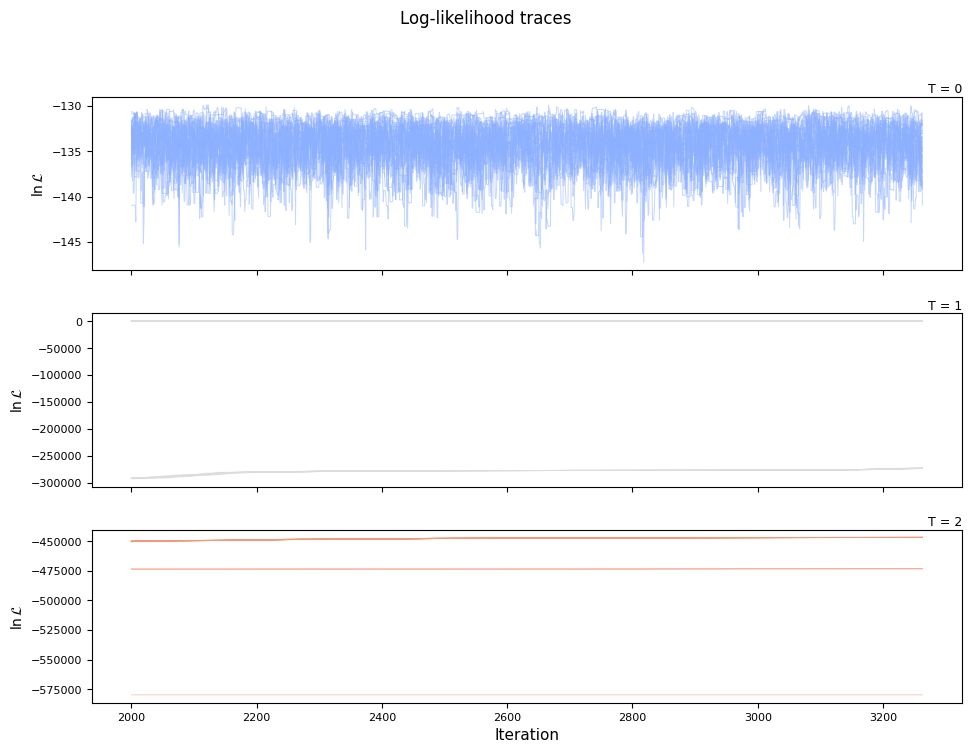

In [8]:
plot_log_like(log_like, temps=list(range(N_temps)), discard=discard)
plt.show()

In [9]:
# if the lgglikelihood shows lost walkers, we filetr these out from the cold chain
if do_filter_lost:
    clean_samples, kept_idx, ll_clean = filter_lost_walkers(
        reader, discard=discard, lower_bound=lost_lower_bound
    )
    # Replace cold-chain samples with the filtered version
    samples_per_temp[0] = clean_samples
    print(f'Cold chain after filtering: {clean_samples.shape}')
else:
    print('Skipping lost-walker filtering.')

Skipping lost-walker filtering.


In [10]:
if do_thin:
    samples_per_temp = cut_samples_autocorr(reader, samples_per_temp, discard=discard)
    print(f'Thinned cold chain: {samples_per_temp[0].shape}')
else:
    print('Skipping autocorrelation thinning.')

Skipping autocorrelation thinning.


### Verify chain convergence
A stable loglikelihood trace indicates that the chains have converged. However, proper convergence diagnostics are needed to confirm this. We plot the loglikelihood trace for the cold chain (T=0) to visually inspect its behavior over iterations. A stable and well-mixed trace suggests good convergence, while trends or large fluctuations point to issues with convergence.

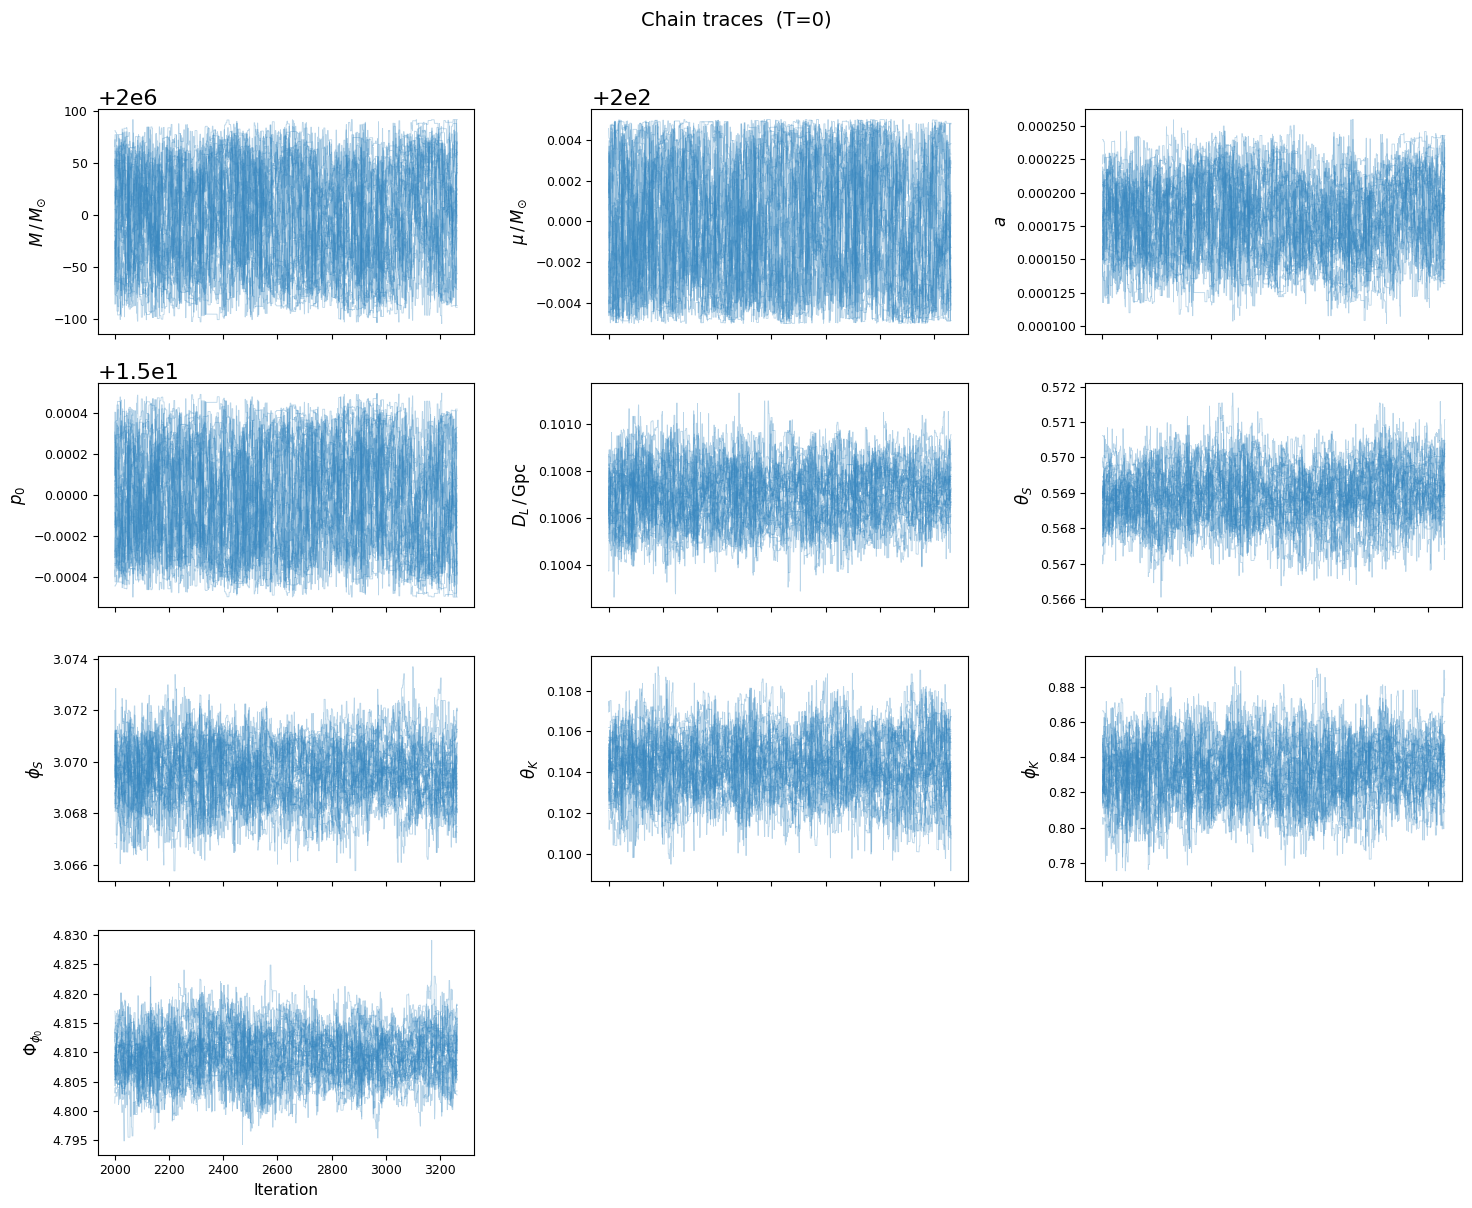

In [11]:
plot_name_traces = f'{run_dir}/test_{test_case}_traces'

fig = plot_chain_convergence(
    reader, param_names,
    discard=discard, temp=0,
    plot_name=plot_name_traces,
)

## Corner plot
Create corner plot kto inspect the posterior distributions of parameters and their correlations

In [14]:
true_vals

array([2.00000000e+06, 2.00000000e+02, 2.00000000e-05, 1.50000000e+01,
       1.00000000e-01, 5.68906246e-01, 3.06956997e+00, 1.12470323e-01,
       7.52438321e-01, 4.80972715e+00])

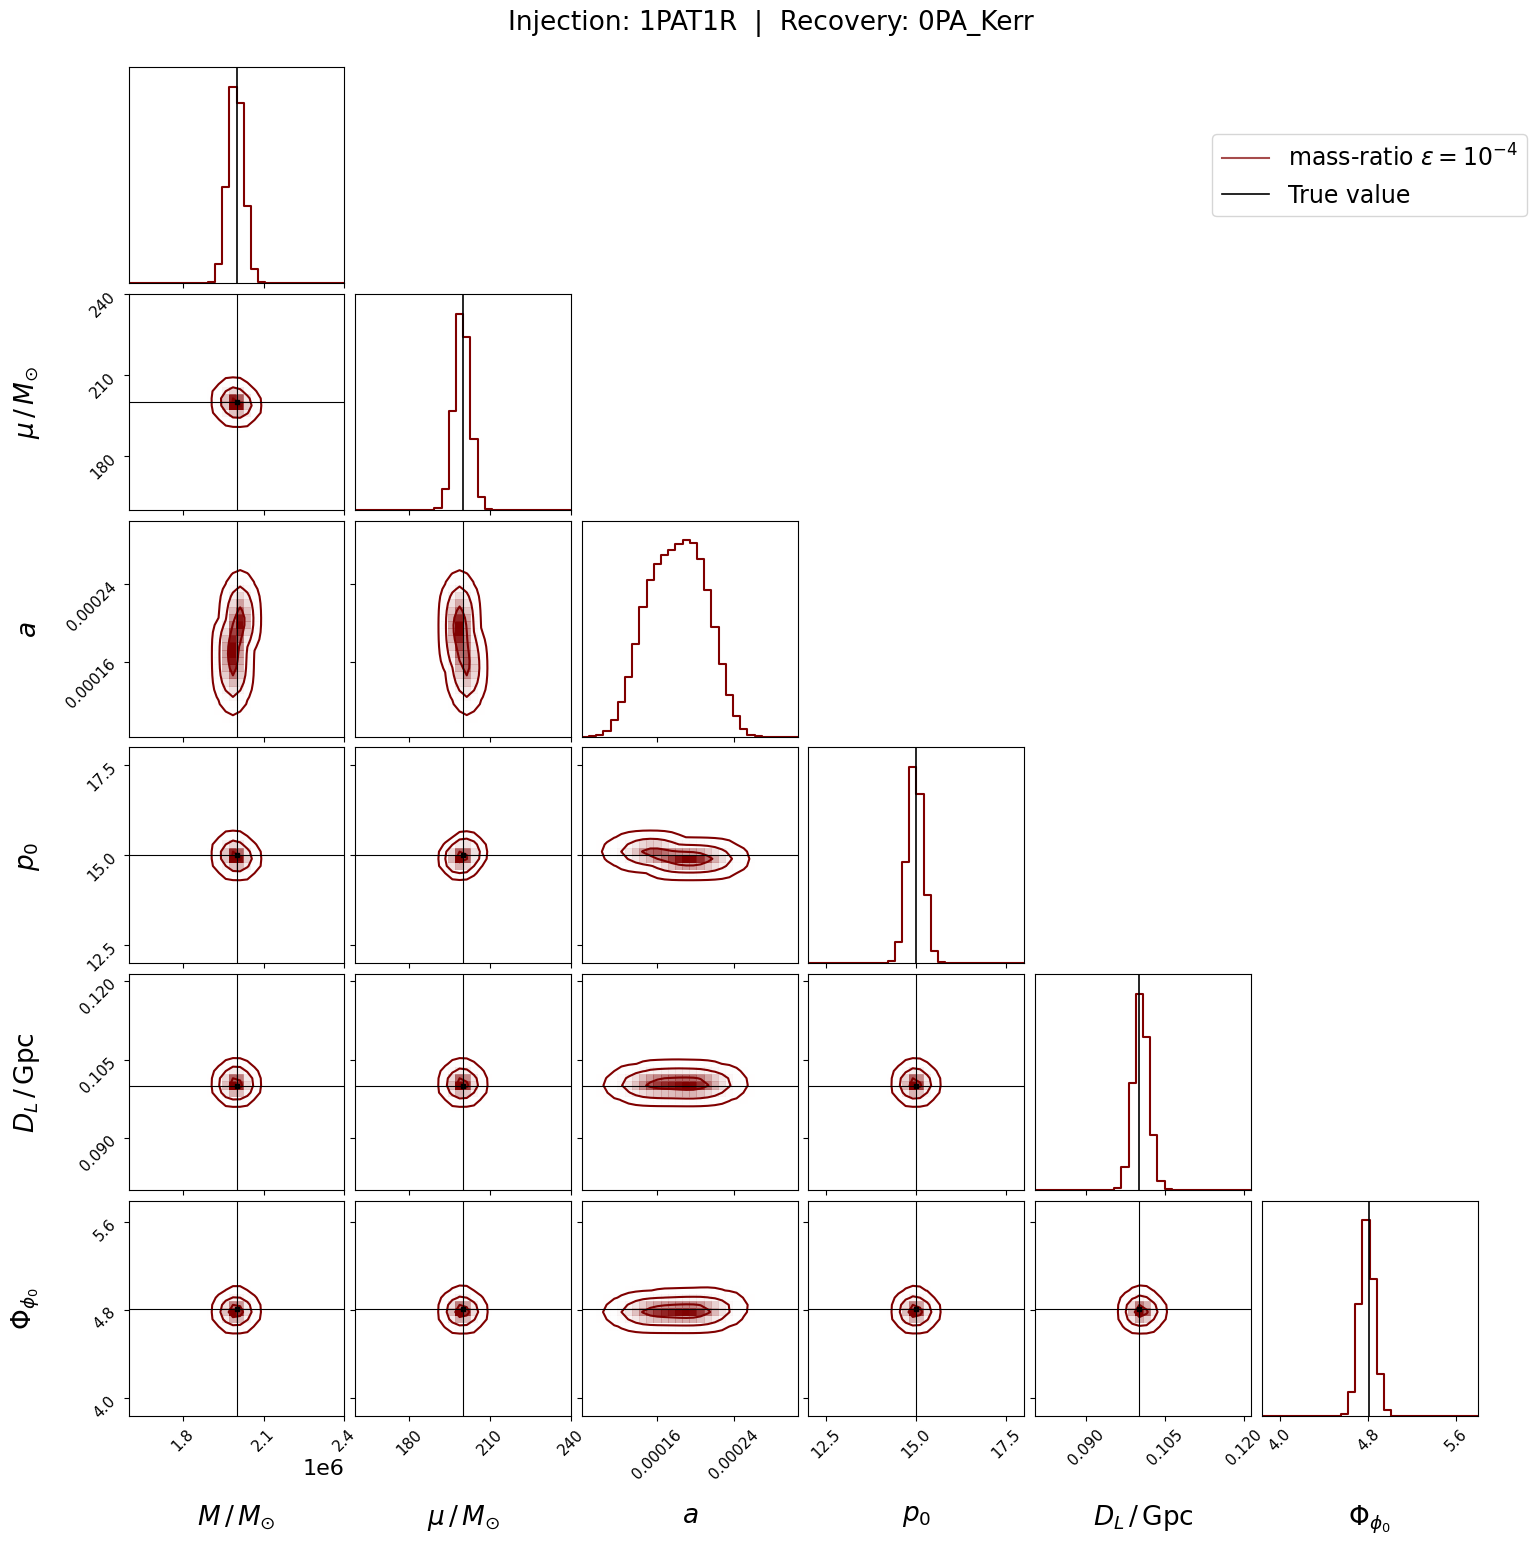

In [12]:
# samples_dict: key = legend label; value = dict with 'color' and 'samples'.
# Add extra entries here to overlay additional posteriors (e.g. higher temps).
samples_dict = {
    r'mass-ratio $\epsilon = 10^{-4}$': {
        'color':   posterior_color,
        'samples': samples_per_temp[0],
    },
}

plot_name_intrinsic = f'{run_dir}/test_{test_case}_corner_intrinsic'

fig = corner_plot(
    samples_dict,
    true_vals,
    param_names,
    inj_model=inj_wf['model'],
    rec_model=rec_wf['model'],
    exclude_sky=True,          # intrinsic + phases only
    plot_name=plot_name_intrinsic,
)
plt.show()

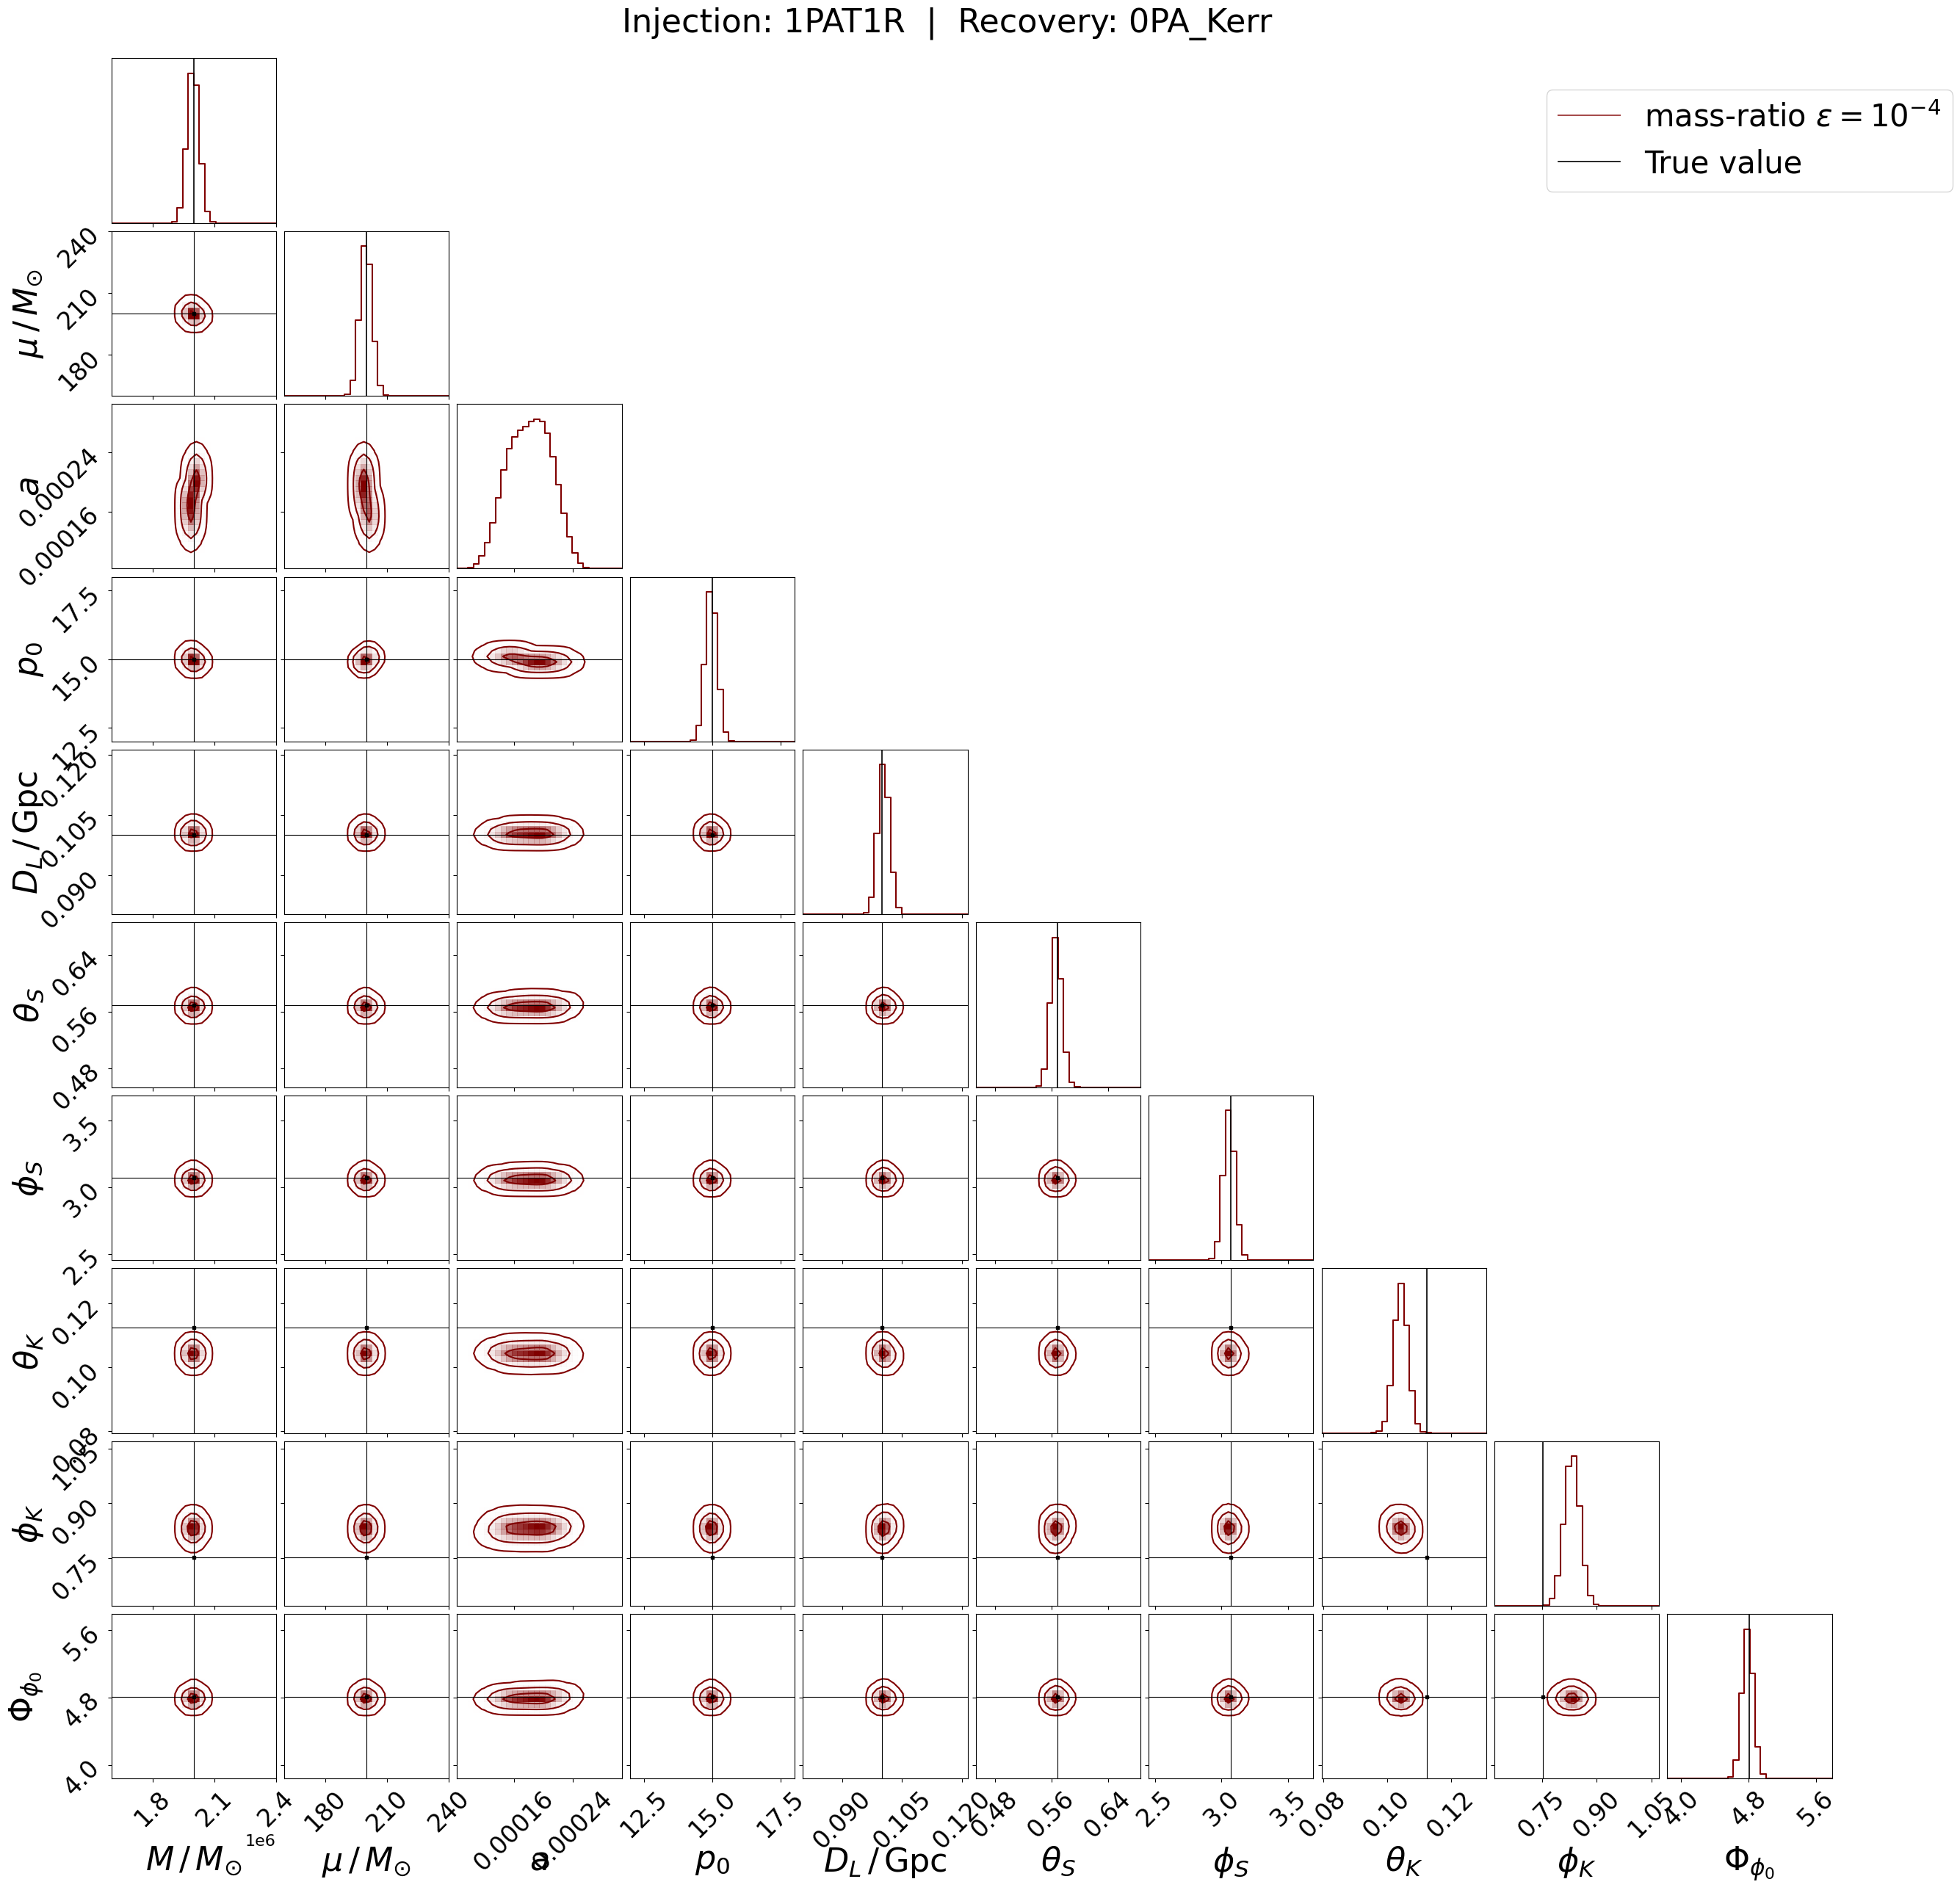

In [13]:
# Full corner plot including sky-angle parameters
plot_name_full = f'{run_dir}/test_{test_case}_corner_full'

fig = corner_plot(
    samples_dict,
    true_vals,
    param_names,
    inj_model=inj_wf['model'],
    rec_model=rec_wf['model'],
    exclude_sky=False,
    plot_name=plot_name_full,
)
plt.show()

If semi-latus rectum and primary mass are completely degenerate, that indicates the injected signal does not have any chirp at all.  

What happened in the secondary mass? Why is this behaving weird? The signal shows some chirp but is not plunging within 2 years. There is only slight curvature of the tracks, that may not be enough to break the degeneracy of the mass-ratio. Also the primary mass is not very well resolved. 

## Sky position

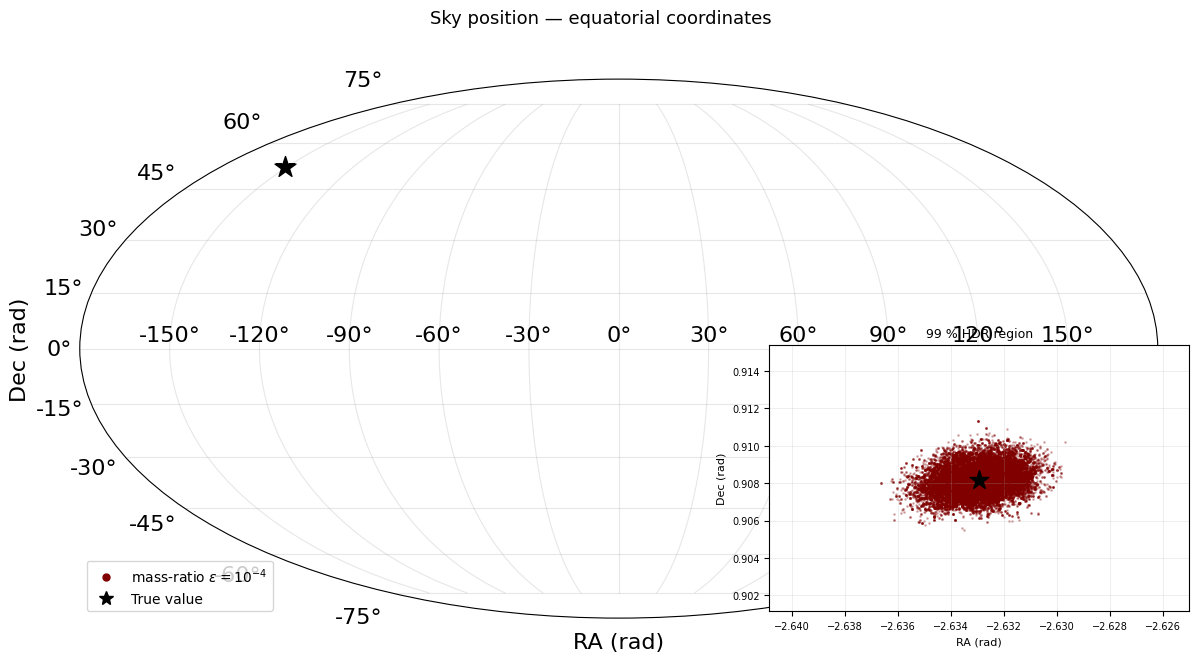

In [14]:
theta_S_true = float(emri['theta_S']) if 'theta_S' in emri else None
phi_S_true   = float(emri['phi_S'])   if 'phi_S'   in emri else None

plot_name_sky = f'{os.getcwd()}/test_{test_case}_sky_position'

fig = plot_sky_position(
    samples_dict,
    param_names,
    true_theta_S=theta_S_true,
    true_phi_S=phi_S_true,
    plot_name=plot_name_sky,
)

## Convergence tests

The following plots track the running marginal variance (diagonal of the sample covariance) as a function of iteration.
In the ideal case, the plot shapes would have the following characteristics:
1. Rises from zero as walkers spread from their starting points                                                                                     2. Passes through a rapid-growth phase during burn-in (We should have filtered this phase during the earlier inspiral)
3. Flattens into a stable plateau: the dashed line (`var[-1]`) should coincide with where the curve stopped changing                                 4. No systematic drift, no sudden jumps in the last iterations for all parameters.                                                                                                
Convergence criteria.                                                                                                                               - The curve has plateaued (zero or near-zero slope in the tail) for all parameters                                                                   
- The dashed asymptote is reached well before the end of the run. If the curve is still rising at the end, more iterations are needed               
- Sudden jumps indicate a walker discovered a new mode late so the variance will then settle to a new plateau, which is fine as long as R-hat also converges.
- A flat curve at a very small value from the start means walkers are stuck (dead sampler issue, no convergence)   

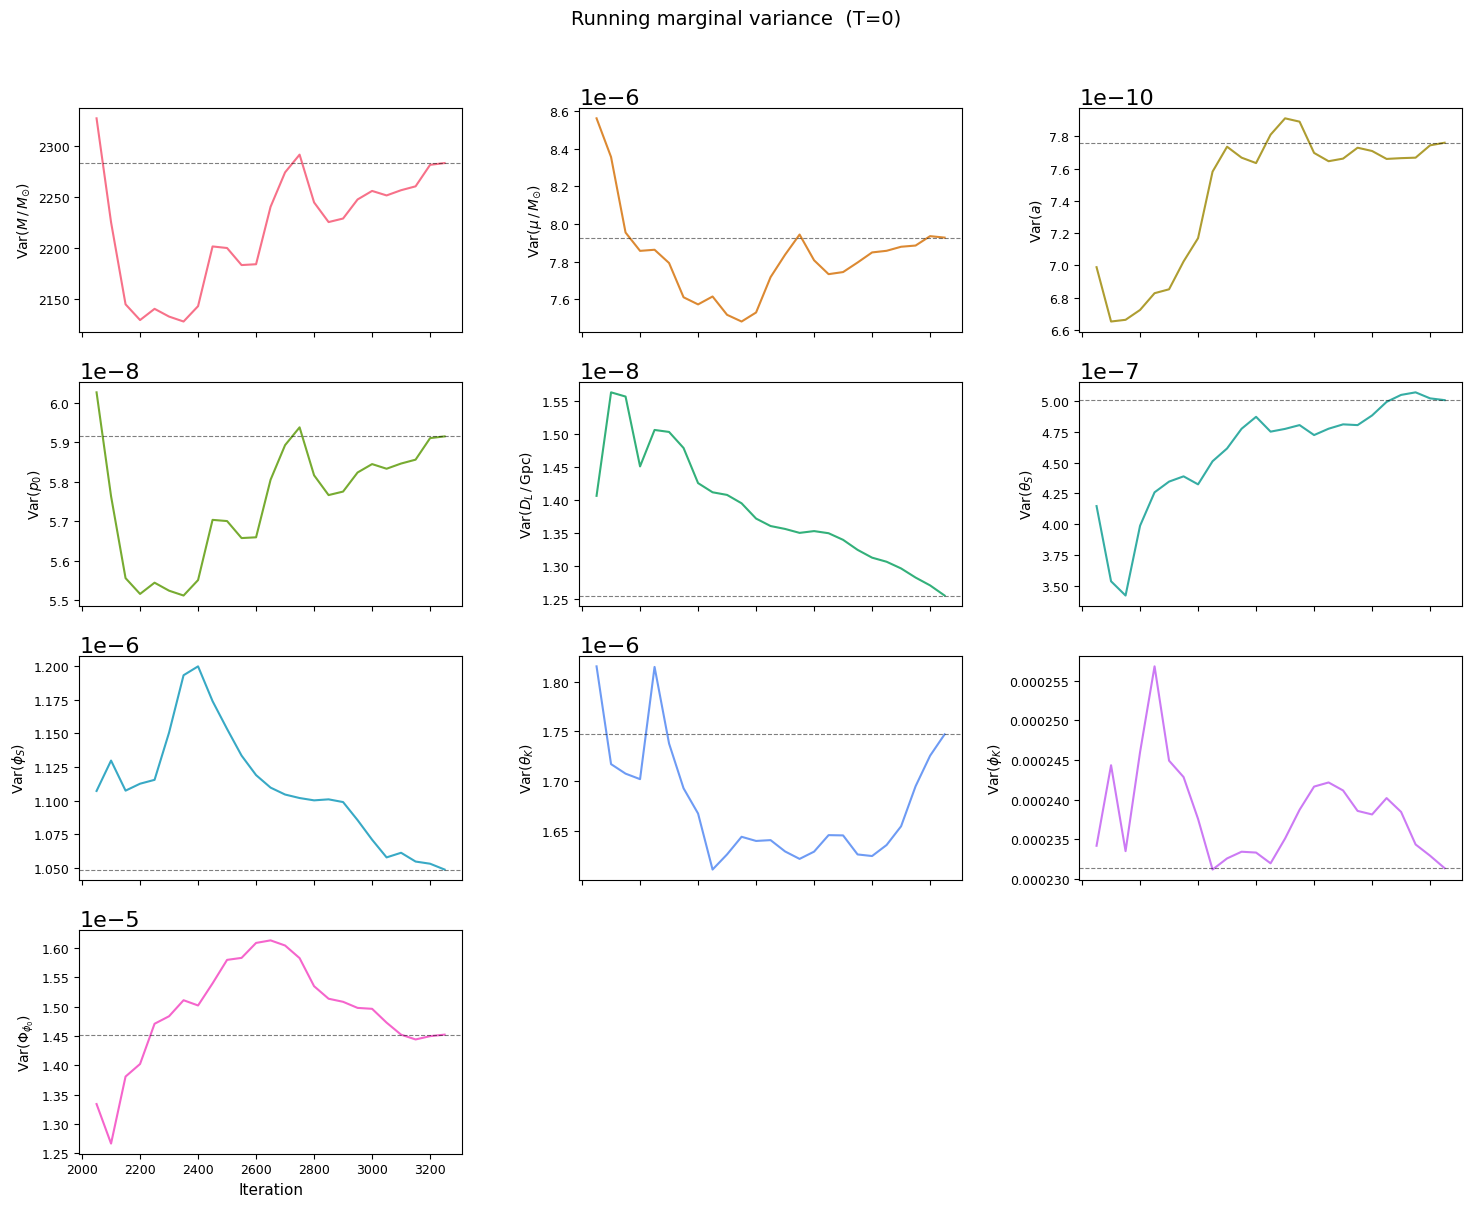

In [15]:
plot_name_cov = f'{run_dir}/test_{test_case}_covariance'

fig = plot_covariance_evolution(
    reader, param_names,
    discard=discard, temp=0, step=50,
    plot_name=plot_name_cov,
)

We can look at the Gelman-Rubin criterion for convergence. R-hat compares between-chain variance to within-chain variance across walkers. Formally, for M walkers of length N:                                          

- $W   = \text{mean of within-walker variances}$                                                                                                     
- $B   = \frac{N}{M-1}  \Sigma (\mu_m - \mu)^2$ -> varaince between difference walkers    
- $\hat{V}   = \frac{N-1}/{N}  W + B/N   $                                                                              - $\hat{R}   = sqrt(\hat{V} / W)$                                                                                     


If all walkers have converged to the same posterior, B/W goes to 1, so R-hat goes to 1. Early on, walkers sample different regions and B >> W, giving R-hat >> 1.                               
                  
In the ideal case, the function `plot_gelman_rubin` computes this running at some intermediate checkpoints:                                                                                    
1. Starts high (commonly 1.1–2+) as walkers haven't mixed                                                                                           
2. Drops monotonically and rapidly during the mixing phase (from parallel tempering)
3. Plateaus and stabilises below the threshold dashed line (default convergence_threshold=1.01, this is a common value for rather strict analysis)   
4. The grey dotted line at 1.0 is the theoretical floor and so the curve should asymptotes towards this value. If it dips below, something went wrong and we need to check.                                                                    
                                                                                                                                            
#### Convergence criterion                                 
We combine the variance evolution of the diagonal elemnts as a function of iteration with the Gelman-Rubin criterion to assess whether the run has concluded or not. All parameters must simultaneously satisfy R-hat < threshold and the curve must be flat a transient dip followed by a rise means the chain is still exploring. The standard rule of thumb is R-hat < 1.01 (strict) or < 1.1 (lenient). Check that the plateau is stable over the last ~30% of iterations.  

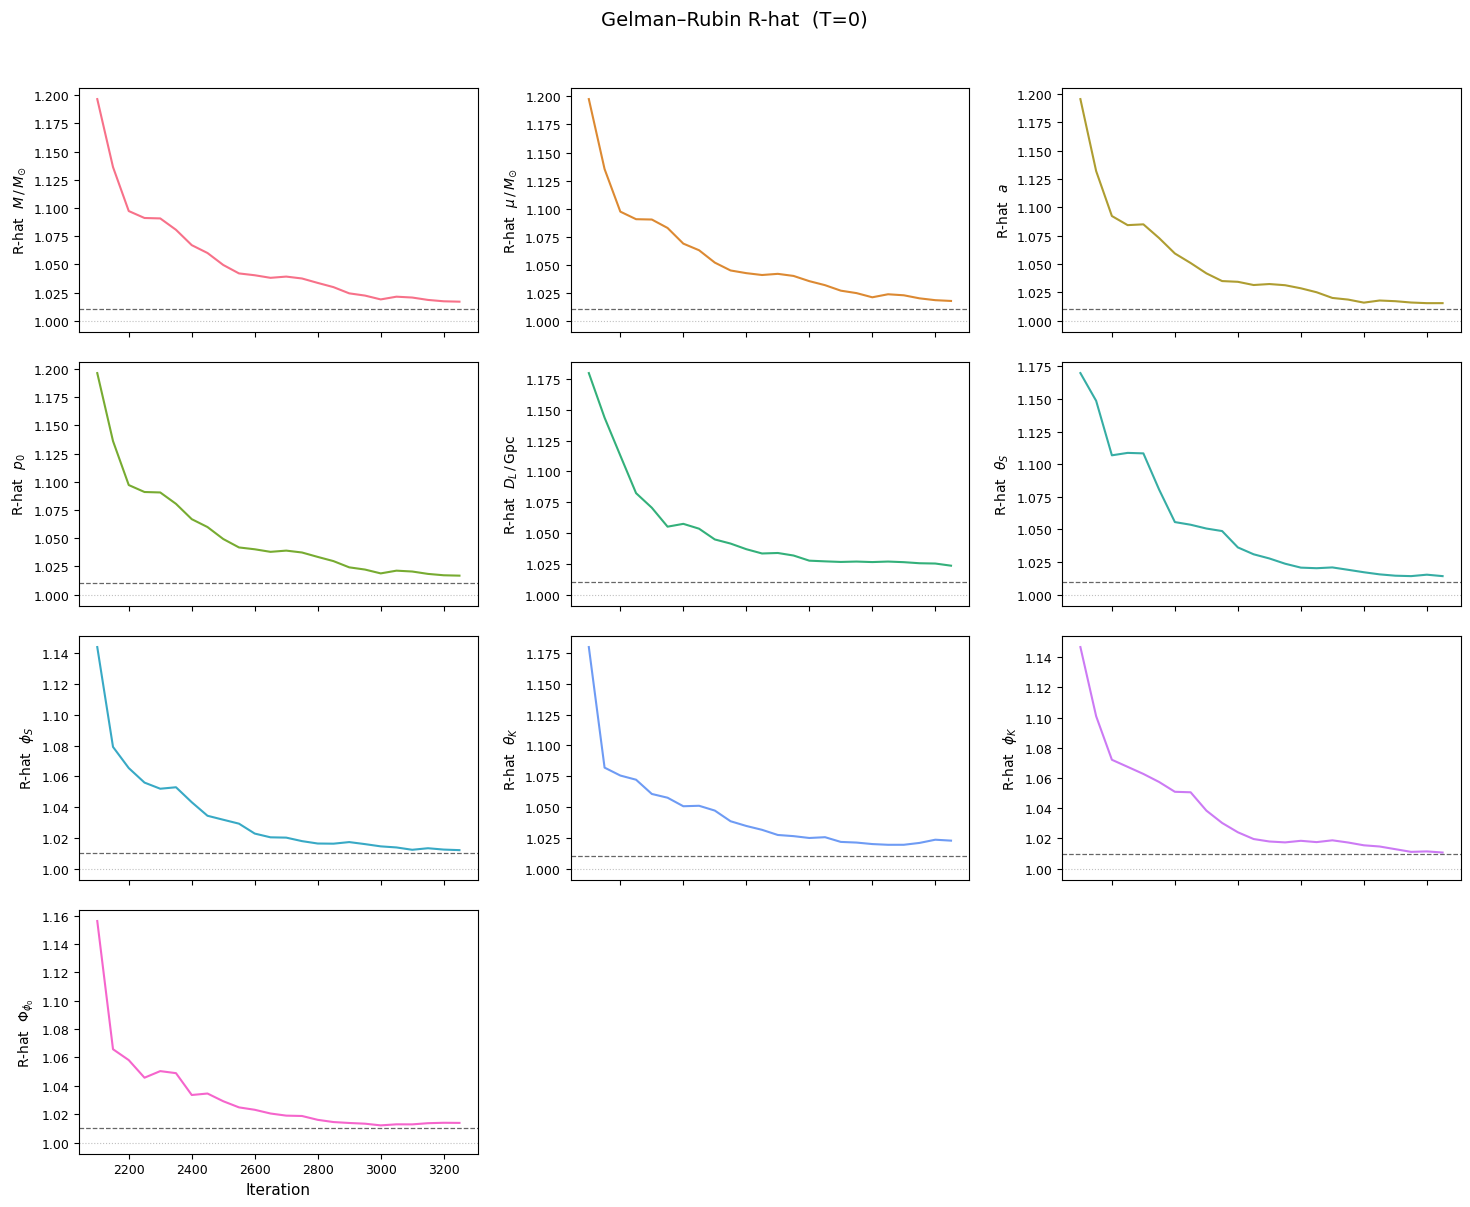

Final R-hat values:
  M                1.0169
  mu               1.0176
  a                1.0155
  p0               1.0169
  d_L              1.0235
  theta_S          1.0142
  phi_S            1.0120
  theta_K          1.0227
  phi_K            1.0107
  Phi_phi0         1.0139


In [16]:
plot_name_rhat = f'{run_dir}/test_{test_case}_gelman_rubin'

rhat = plot_gelman_rubin(
    reader, param_names,
    discard=discard, temp=0, step=50,
    convergence_threshold=1.01,
    plot_name=plot_name_rhat,
)
print('Final R-hat values:')
for name, rh in zip(param_names, rhat[-1]):
    print(f'  {name:<16} {rh:.4f}')

## Some extra plots
Use the statistical tools in seaborn to inspect properties of the inferred posterior distributions, such as skewness, multimodality, etc. This can help identify potential issues with the sampling process or the model fit.

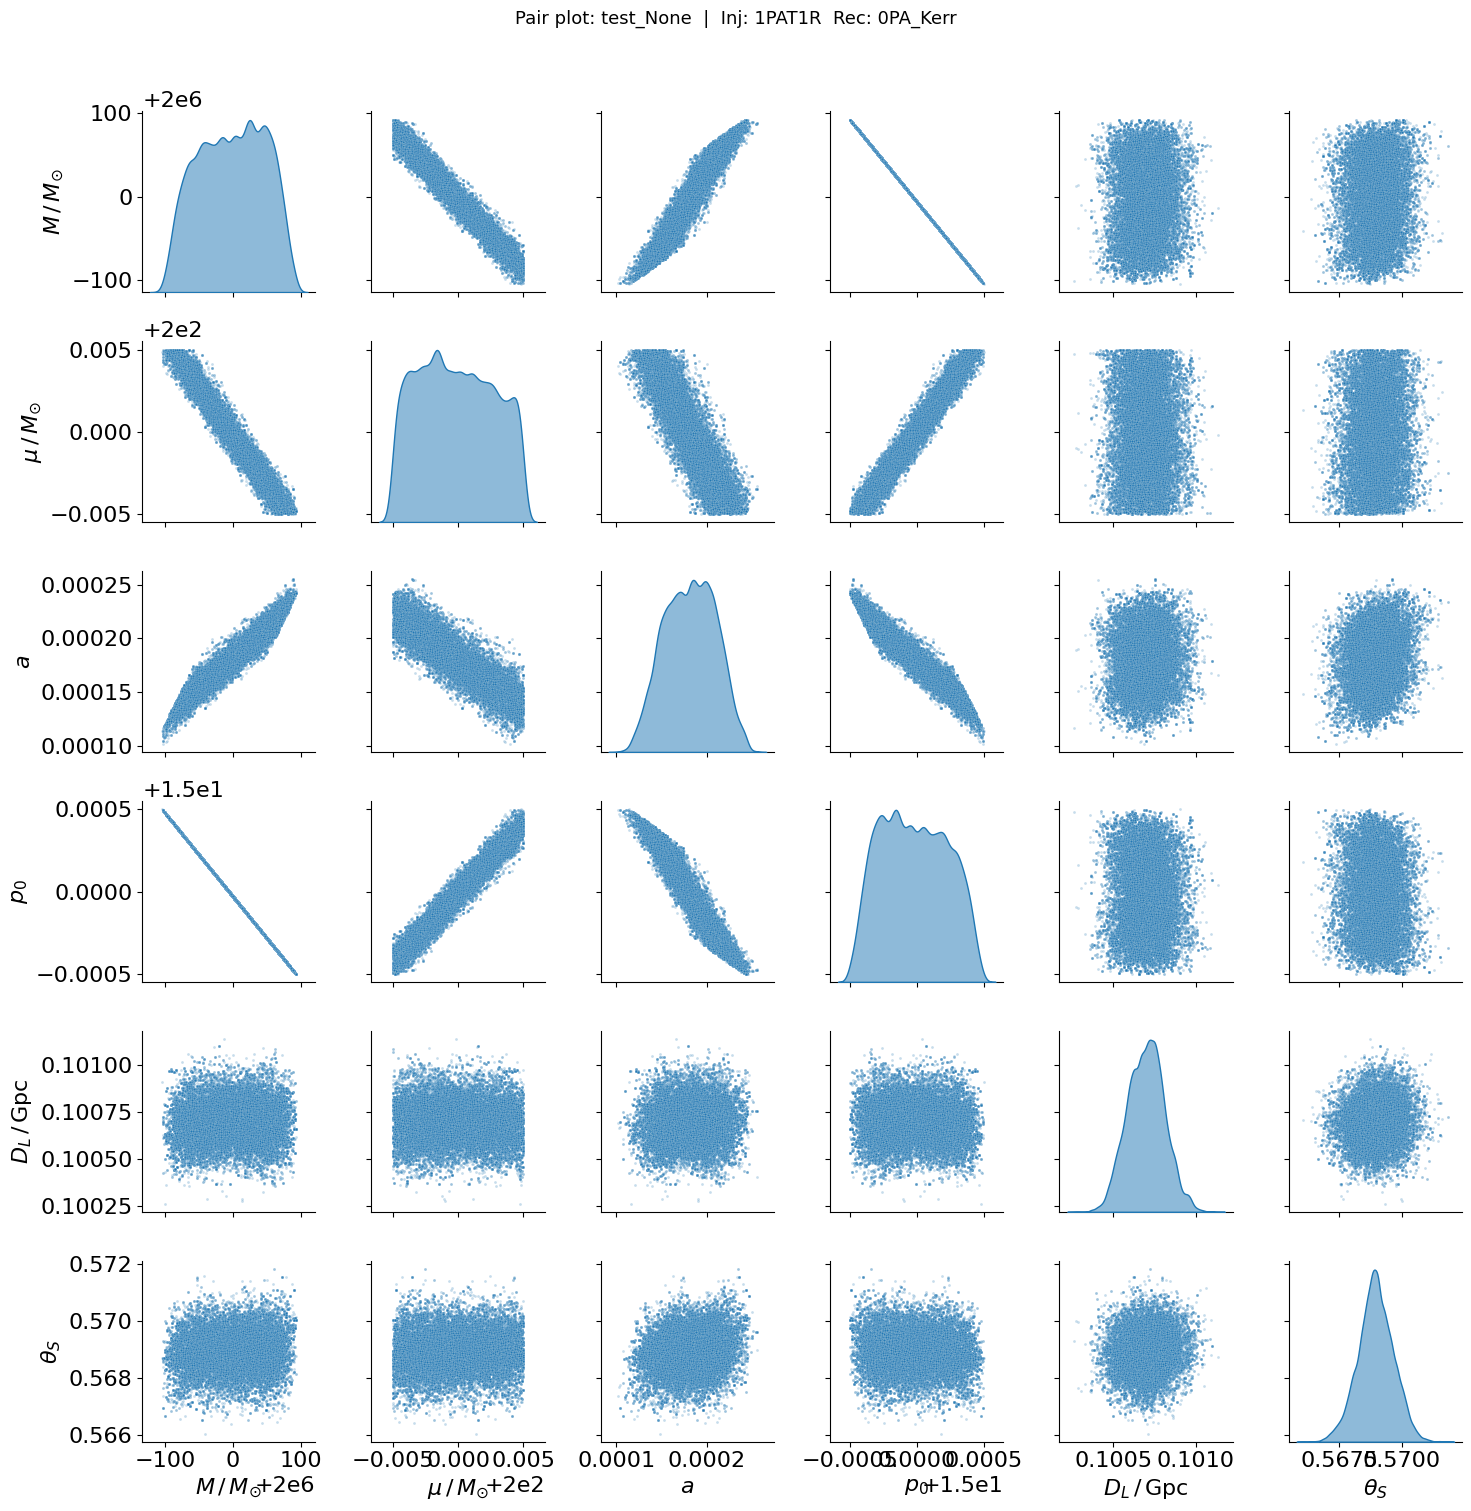

/vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/src/analysis.py:975: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


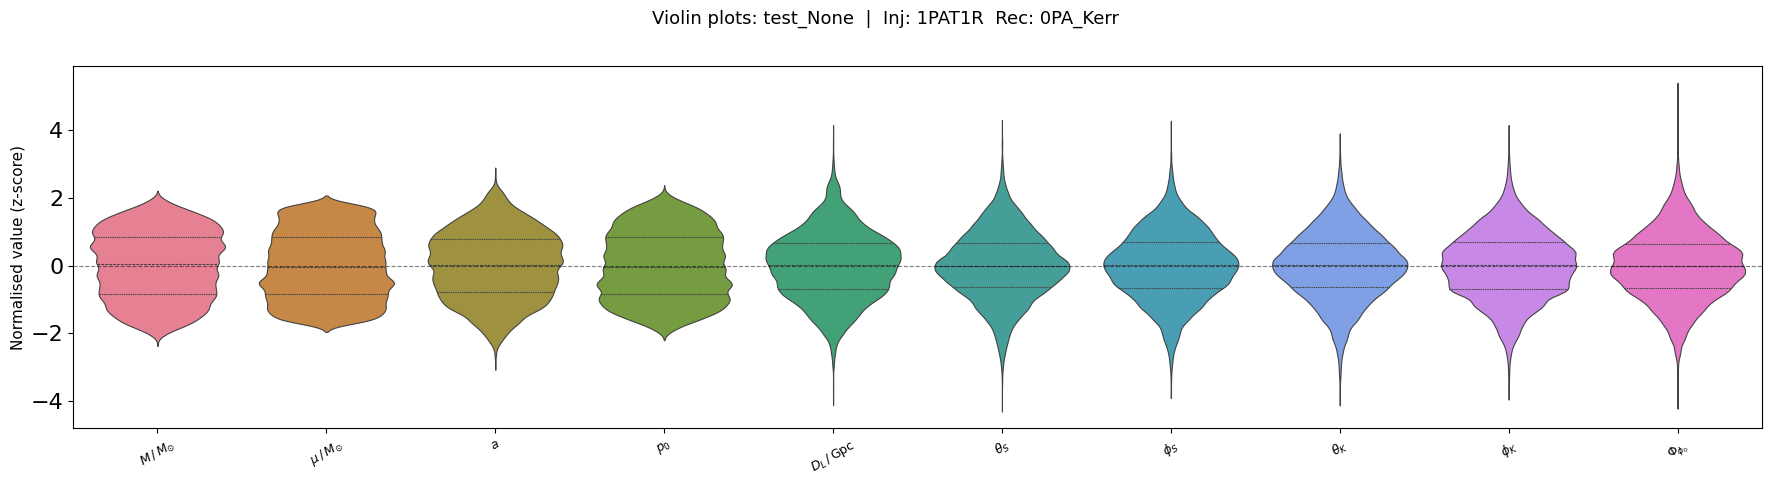

In [17]:
plot_name_sb = f'{run_dir}/test_{test_case}_seaborn'

title = (
    f'test_{test_case}  |  '
    f"Inj: {inj_wf['model']}  Rec: {rec_wf['model']}"
)

fig = plot_seaborn_diagnostics(
    samples_per_temp[0],
    param_names,
    title=title,
    max_pair_params=6,
    plot_name=plot_name_sb,
)

## Quantitative summary

In [18]:
cold_samples = samples_per_temp[0]   # (N_samples, N_params)

rows = []
for k, name in enumerate(param_names):
    col   = cold_samples[:, k]
    med   = np.median(col)
    lo68, hi68 = np.percentile(col, [16.0, 84.0])
    lo90, hi90 = np.percentile(col, [ 5.0, 95.0])
    half_68    = (hi68 - lo68) / 2.0
    bias_sigma = (med - true_vals[k]) / half_68 if half_68 > 0 else float('nan')
    in_90ci    = lo90 <= true_vals[k] <= hi90
    rows.append(dict(
        name       = name,
        true       = true_vals[k],
        median     = med,
        lo68       = lo68,
        hi68       = hi68,
        ci90_width = hi90 - lo90,
        bias_sigma = bias_sigma,
        in_90ci    = in_90ci,
    ))

header = (f"{'Param':<16}  {'True':>12}  {'Median':>12}  "
          f"{'[16th':>12}  {'84th]':>12}  {'90% CI':>10}  {'bias/σ':>7}  {'in 90%CI':>9}")
sep = "-" * len(header)
print(header)
print(sep)
for r in rows:
    flag = "yes" if r['in_90ci'] else "NO"
    print(f"{r['name']:<16}  {r['true']:>12.5g}  {r['median']:>12.5g}  "
          f"{r['lo68']:>12.5g}  {r['hi68']:>12.5g}  {r['ci90_width']:>10.4g}  "
          f"{r['bias_sigma']:>7.2f}  {flag:>9}")
print(sep)
print(f"\n{'N cold samples:':<20} {len(cold_samples)}")


Param                     True        Median         [16th         84th]      90% CI   bias/σ   in 90%CI
--------------------------------------------------------------------------------------------------------
M                        2e+06         2e+06    1.9999e+06    2.0001e+06       150.5    -0.00        yes
mu                         200           200           200           200    0.008898    -0.08        yes
a                        2e-05    0.00018186    0.00015064    0.00021081   9.003e-05     5.38         NO
p0                          15            15            15            15   0.0007666    -0.11        yes
d_L                        0.1        0.1007       0.10058       0.10081   0.0003666     6.29         NO
theta_S                0.56891       0.56894       0.56826       0.56965    0.002346     0.04        yes
phi_S                   3.0696        3.0695        3.0685        3.0706     0.00333    -0.03        yes
theta_K                0.11247       0.10433       0.10

## Comparison plots

In [19]:
sampling_dir

'/vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/sampling_data'

### Test case, include / exclude 1PA effects
We have several runs with the test case: including all 1PA effects, and turning off certain effects: 
- evolution of the primary
- corrected 1PA amplitudes
These are the two included flags in FEW 1PAT1R. 

In [15]:
# Hardcoded paths to the run directories being compared
full_1PA = f'{sampling_dir}/test_1PA_full_2026-04-28_07-28-40'
amps_off = f'{sampling_dir}/test_amps_off_2026-04-29_02-35-42'
evolution_primary_off = f'{sampling_dir}/test_evolution_primary_off_2026-04-29_02-36-38'

# Load configs for each run to derive the correct parameter lists
config_full_1PA = param_load(f'./config/config_test_full_1PA.yaml')
config_amps_off = param_load(f'./config/config_test_amps_off.yaml')
config_evolution_primary_off = param_load(f'./config/config_test_evolution_primary_off.yaml')

# Derive sampled parameters
param_names_full, injected_vals = sampled_params_from_config(config_full_1PA)
param_names_amps, _ = sampled_params_from_config(config_amps_off)
param_names_evol, _ = sampled_params_from_config(config_evolution_primary_off)

print(f'Full 1PA params ({len(param_names_full)}): {param_names_full}')
print(f'Amps Off params ({len(param_names_amps)}): {param_names_amps}')
print(f'Evol Primary Off params ({len(param_names_evol)}): {param_names_evol}')

# Locate HDF5 backends using the hard-coded paths
h5_full = glob.glob(os.path.join(full_1PA, 'SamplingResults_*.h5'))
h5_amps = glob.glob(os.path.join(amps_off, 'SamplingResults_*.h5'))
h5_evol = glob.glob(os.path.join(evolution_primary_off, 'SamplingResults_*.h5'))

# Validation and Loading
for label, h5_list in zip(['Full', 'Amps Off', 'Evol Off'], [h5_full, h5_amps, h5_evol]):
    if not h5_list:
        raise FileNotFoundError(f'No HDF5 found for {label} run.')
    print(f'\nLoading {label}: {h5_list[0]}')

Full 1PA params (11): ['M', 'mu', 'a', 'p0', 'chi2', 'd_L', 'theta_S', 'phi_S', 'theta_K', 'phi_K', 'Phi_phi0']
Amps Off params (11): ['M', 'mu', 'a', 'p0', 'chi2', 'd_L', 'theta_S', 'phi_S', 'theta_K', 'phi_K', 'Phi_phi0']
Evol Primary Off params (11): ['M', 'mu', 'a', 'p0', 'chi2', 'd_L', 'theta_S', 'phi_S', 'theta_K', 'phi_K', 'Phi_phi0']

Loading Full: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/sampling_data/test_1PA_full_2026-04-28_07-28-40/SamplingResults_test_1PA_full_fixedx_I0_1.0_e0_0.0_Phi_theta0_0.635376120342196_Phi_r0_4.2638433178190684_2026-04-28_07-28-40.h5

Loading Amps Off: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/sampling_data/test_amps_off_2026-04-29_02-35-42/SamplingResults_test_amps_off_fixedx_I0_1.0_e0_0.0_Phi_theta0_0.635376120342196_Phi_r0_4.2638433178190684_2026-04-29_02-35-42.h5

Loading Evol Off: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/val

In [16]:
injected_vals

array([2.00000000e+06, 2.00000000e+01, 2.00000000e-05, 9.00000000e+00,
       9.00000000e-01, 1.00000000e-01, 5.68906246e-01, 3.06956997e+00,
       1.12470323e-01, 7.52438321e-01, 4.80972715e+00])

In [17]:
# Set discard (burn-in) values for each run
discard_full = 2178
discard_amps = 1268
discard_evol = 1000 

# Load 'Full 1PA' samples
named_full, reader_full, log_like_full, (N_iters_full, N_temps_full, N_walkers_full, _) = \
    load_samples_named(h5_full[0], param_names_full, discard=discard_full)

# Load 'Amps Off' samples
named_amps, reader_amps, log_like_amps, (N_iters_amps, N_temps_amps, N_walkers_amps, _) = \
    load_samples_named(h5_amps[0], param_names_amps, discard=discard_amps)

# Load 'Evolution Primary Off' samples
named_evol, reader_evol, log_like_evol, (N_iters_evol, N_temps_evol, N_walkers_evol, _) = \
    load_samples_named(h5_evol[0], param_names_evol, discard=discard_evol)

# Print summary for all three
print(f'Full 1PA: {N_iters_full} iters × {N_temps_full} temps × {N_walkers_full} walkers')
print(f'Amps Off: {N_iters_amps} iters × {N_temps_amps} temps × {N_walkers_amps} walkers')
print(f'Evol Off: {N_iters_evol} iters × {N_temps_evol} temps × {N_walkers_evol} walkers')

Full 1PA: 689 iters × 3 temps × 30 walkers
Amps Off: 1059 iters × 3 temps × 30 walkers
Evol Off: 1005 iters × 3 temps × 30 walkers


In [18]:
1957 - 689

1268

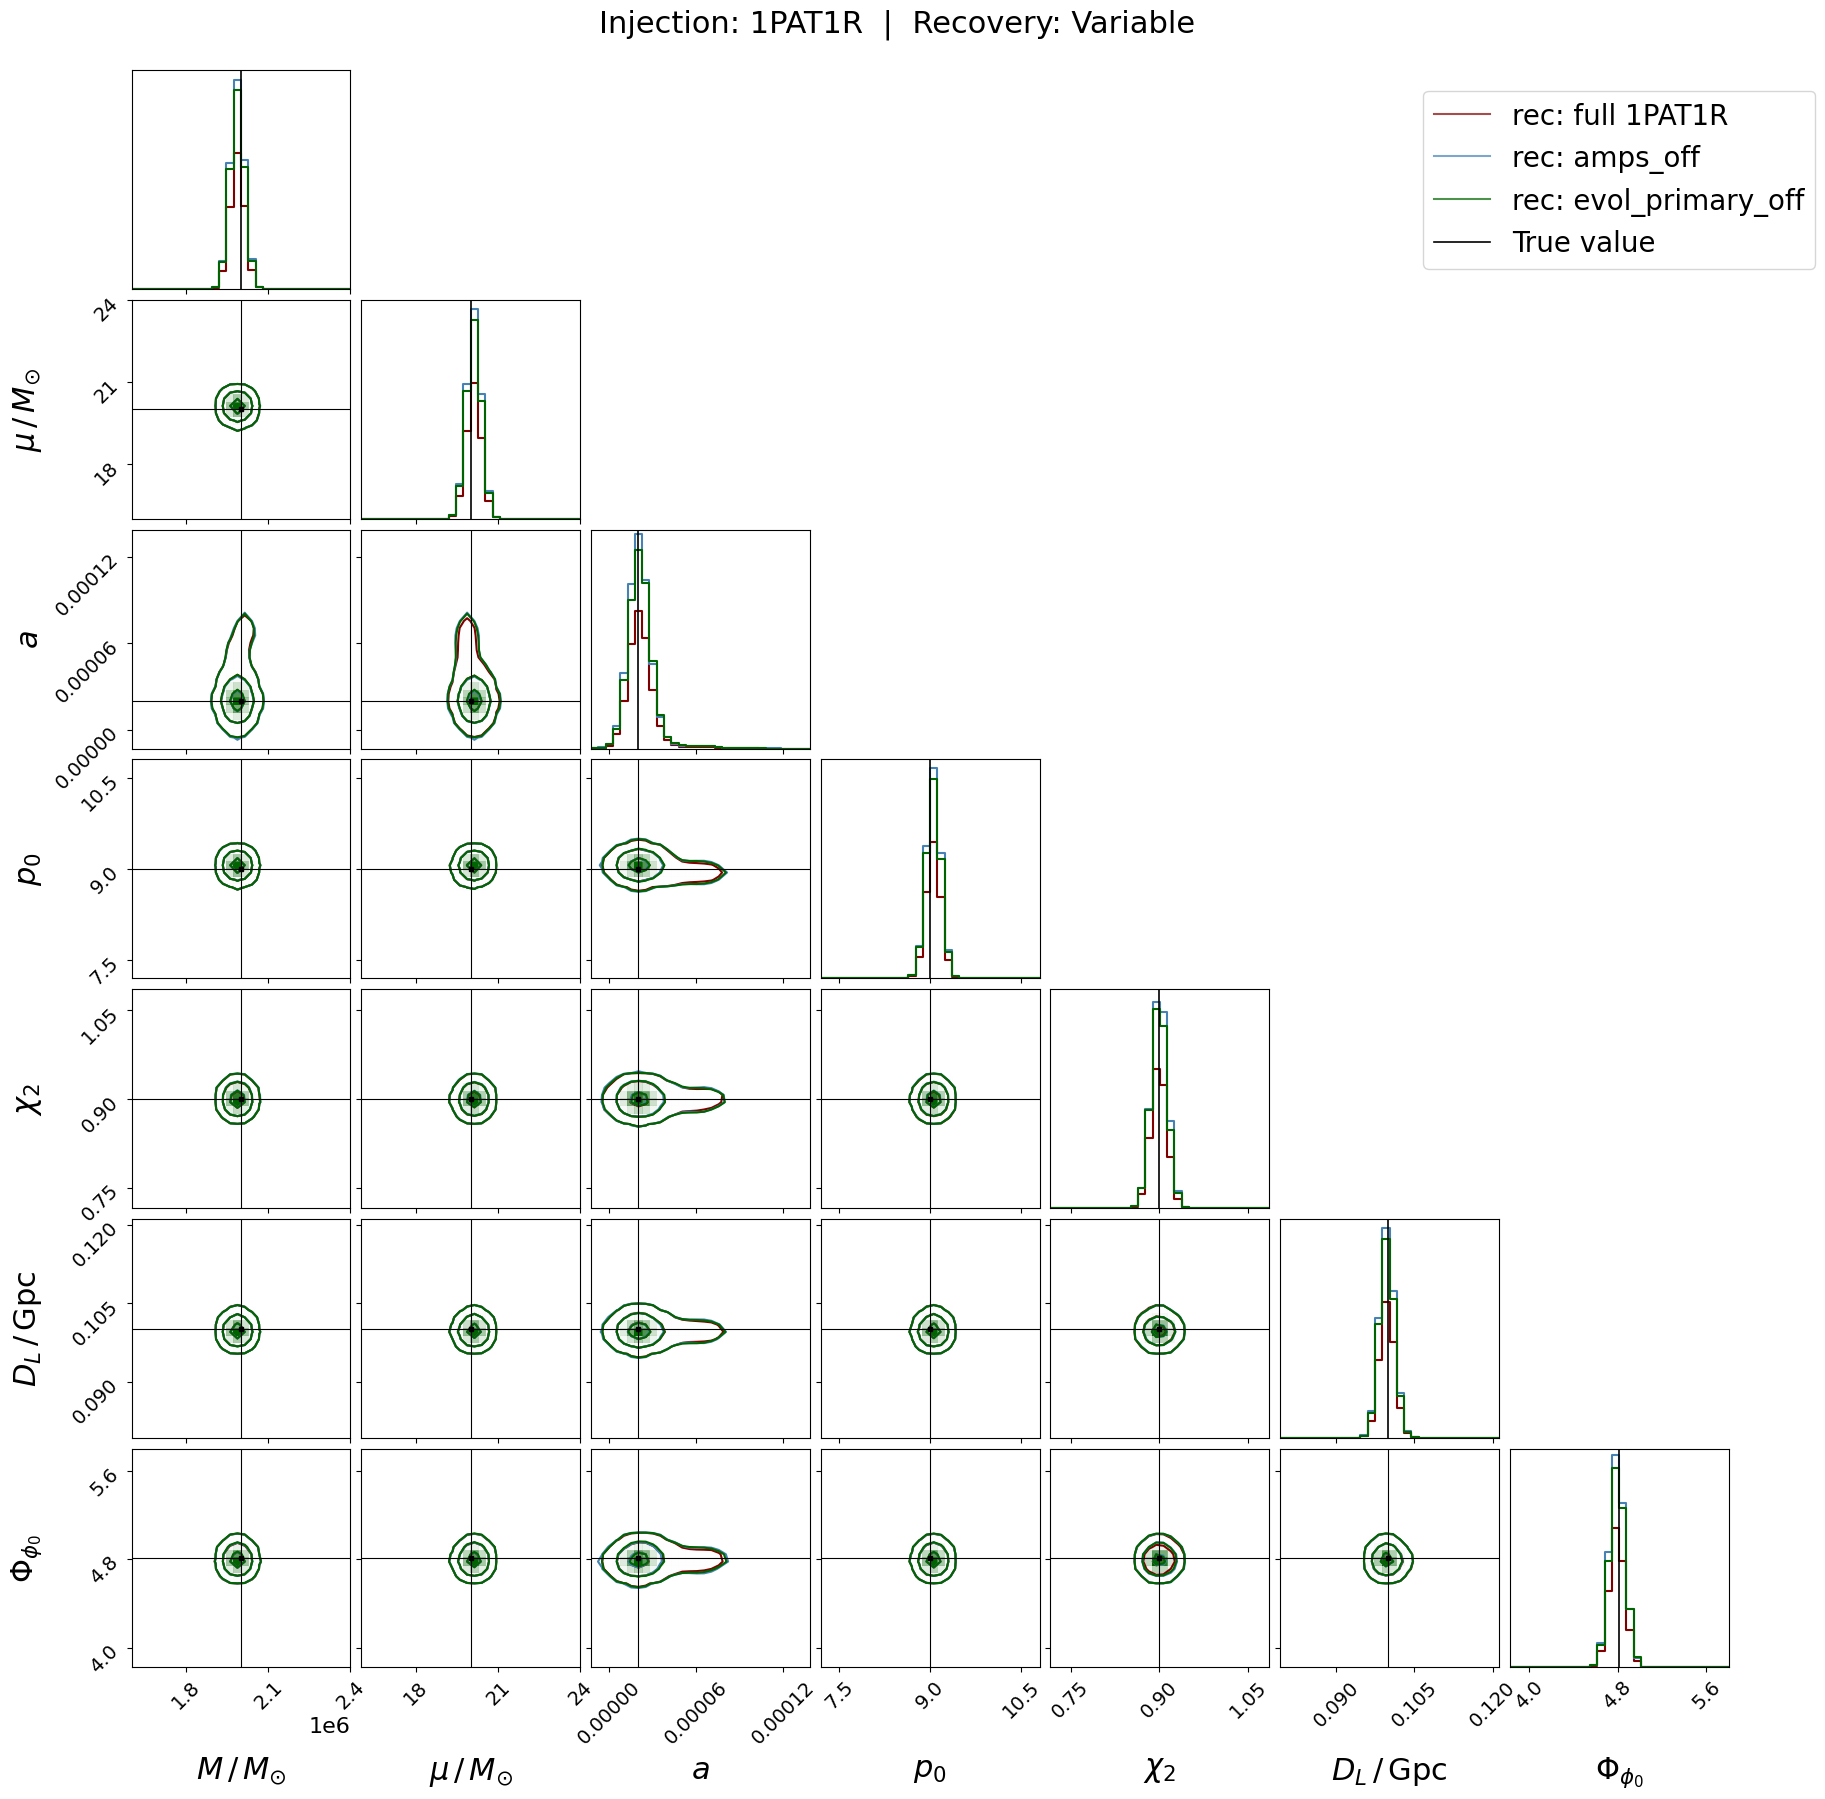

In [19]:
# samples_dict uses the named-dict format so corner_plot matches params by name.
# param_names_1PA is the reference (superset that includes chi2).
# corner_plot automatically intersects with 0PA's keys, so chi2 is excluded from
# the overlay and every remaining parameter lands on the correct axis.
samples_dict_1PA = {
    r'rec: full 1PAT1R': {
        'color':   'maroon',
        'samples': named_full,
    },
    r'rec: amps_off': {
        'color':   'steelblue',
        'samples': named_amps,
    },
    r'rec: evol_primary_off': {
        'color':   'darkgreen',
        'samples': named_evol,
    },
}

plot_name_intrinsic = f'{os.getcwd()}/Comparison_test_case_corner_intrinsic'

fig = corner_plot(
    samples_dict_1PA,
    injected_vals,
    param_names_full, 
    inj_model='1PAT1R',
    rec_model=r'Variable',
    exclude_sky=True,
    plot_name=plot_name_intrinsic,
)
plt.show()

### Mass-ratio $\epsilon = 10^{-4}$

In [24]:
# Hardcoded paths to the two run directories being compared
inj_1PA_rec_0PA_dir = f'{sampling_dir}/inj_1PA_rec_0PA_eps_e-4_2026-04-28_07-29-27'
inj_1PA_rec_1PA_dir = f'{sampling_dir}/inj_1PA_rec_1PA_eps_e-4_2026-04-28_01-41-10'

# Load configs for each run to derive the correct parameter lists
config_0PA = param_load(f'./config/config_inj_1PA_rec_0PA_eps_e-4.yaml')
config_1PA = param_load(f'./config/config_inj_1PA_rec_1PA_eps_e-4.yaml')

param_names_0PA, _           = sampled_params_from_config(config_0PA)
param_names_1PA, true_vals_comparison = sampled_params_from_config(config_1PA)

print(f'0PA sampled params ({len(param_names_0PA)}): {param_names_0PA}')
print(f'1PA sampled params ({len(param_names_1PA)}): {param_names_1PA}')

# Locate HDF5 backends
h5_0PA = glob.glob(os.path.join(inj_1PA_rec_0PA_dir, 'SamplingResults_*.h5'))
h5_1PA = glob.glob(os.path.join(inj_1PA_rec_1PA_dir, 'SamplingResults_*.h5'))
if not h5_0PA:
    raise FileNotFoundError(f'No HDF5 found in {inj_1PA_rec_0PA_dir}')
if not h5_1PA:
    raise FileNotFoundError(f'No HDF5 found in {inj_1PA_rec_1PA_dir}')

print(f'\nLoading 0PA: {h5_0PA[0]}')
print(f'Loading 1PA: {h5_1PA[0]}')

0PA sampled params (10): ['M', 'mu', 'a', 'p0', 'd_L', 'theta_S', 'phi_S', 'theta_K', 'phi_K', 'Phi_phi0']
1PA sampled params (11): ['M', 'mu', 'a', 'p0', 'chi2', 'd_L', 'theta_S', 'phi_S', 'theta_K', 'phi_K', 'Phi_phi0']

Loading 0PA: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/sampling_data/inj_1PA_rec_0PA_eps_e-4_2026-04-28_07-29-27/SamplingResults_inj_1PA_rec_0PA_eps_e-4_fixedx_I0_1.0_e0_0.0_Phi_theta0_0.635376120342196_Phi_r0_4.2638433178190684_2026-04-28_07-29-27.h5
Loading 1PA: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/sampling_data/inj_1PA_rec_1PA_eps_e-4_2026-04-28_01-41-10/SamplingResults_inj_1PA_rec_1PA_eps_e-4_fixedx_I0_1.0_e0_0.0_Phi_theta0_0.635376120342196_Phi_r0_4.2638433178190684_2026-04-28_01-41-10.h5


In [25]:
discard_0PA = 2000
discard_1PA = 1992

# Load into named dicts: {param_name: ndarray(N_temps, N_iters, N_walkers)}
named_0PA, reader_0PA, log_like_0PA, (N_iters_0PA, N_temps_0PA, N_walkers_0PA, _) = \
    load_samples_named(h5_0PA[0], param_names_0PA, discard=discard_0PA)

named_1PA, reader_1PA, log_like_1PA, (N_iters_1PA, N_temps_1PA, N_walkers_1PA, _) = \
    load_samples_named(h5_1PA[0], param_names_1PA, discard=discard_1PA)

print(f'0PA: {N_iters_0PA} iters × {N_temps_0PA} temps × {N_walkers_0PA} walkers')
print(f'1PA: {N_iters_1PA} iters × {N_temps_1PA} temps × {N_walkers_1PA} walkers')

0PA: 1264 iters × 3 temps × 30 walkers
1PA: 1264 iters × 3 temps × 30 walkers


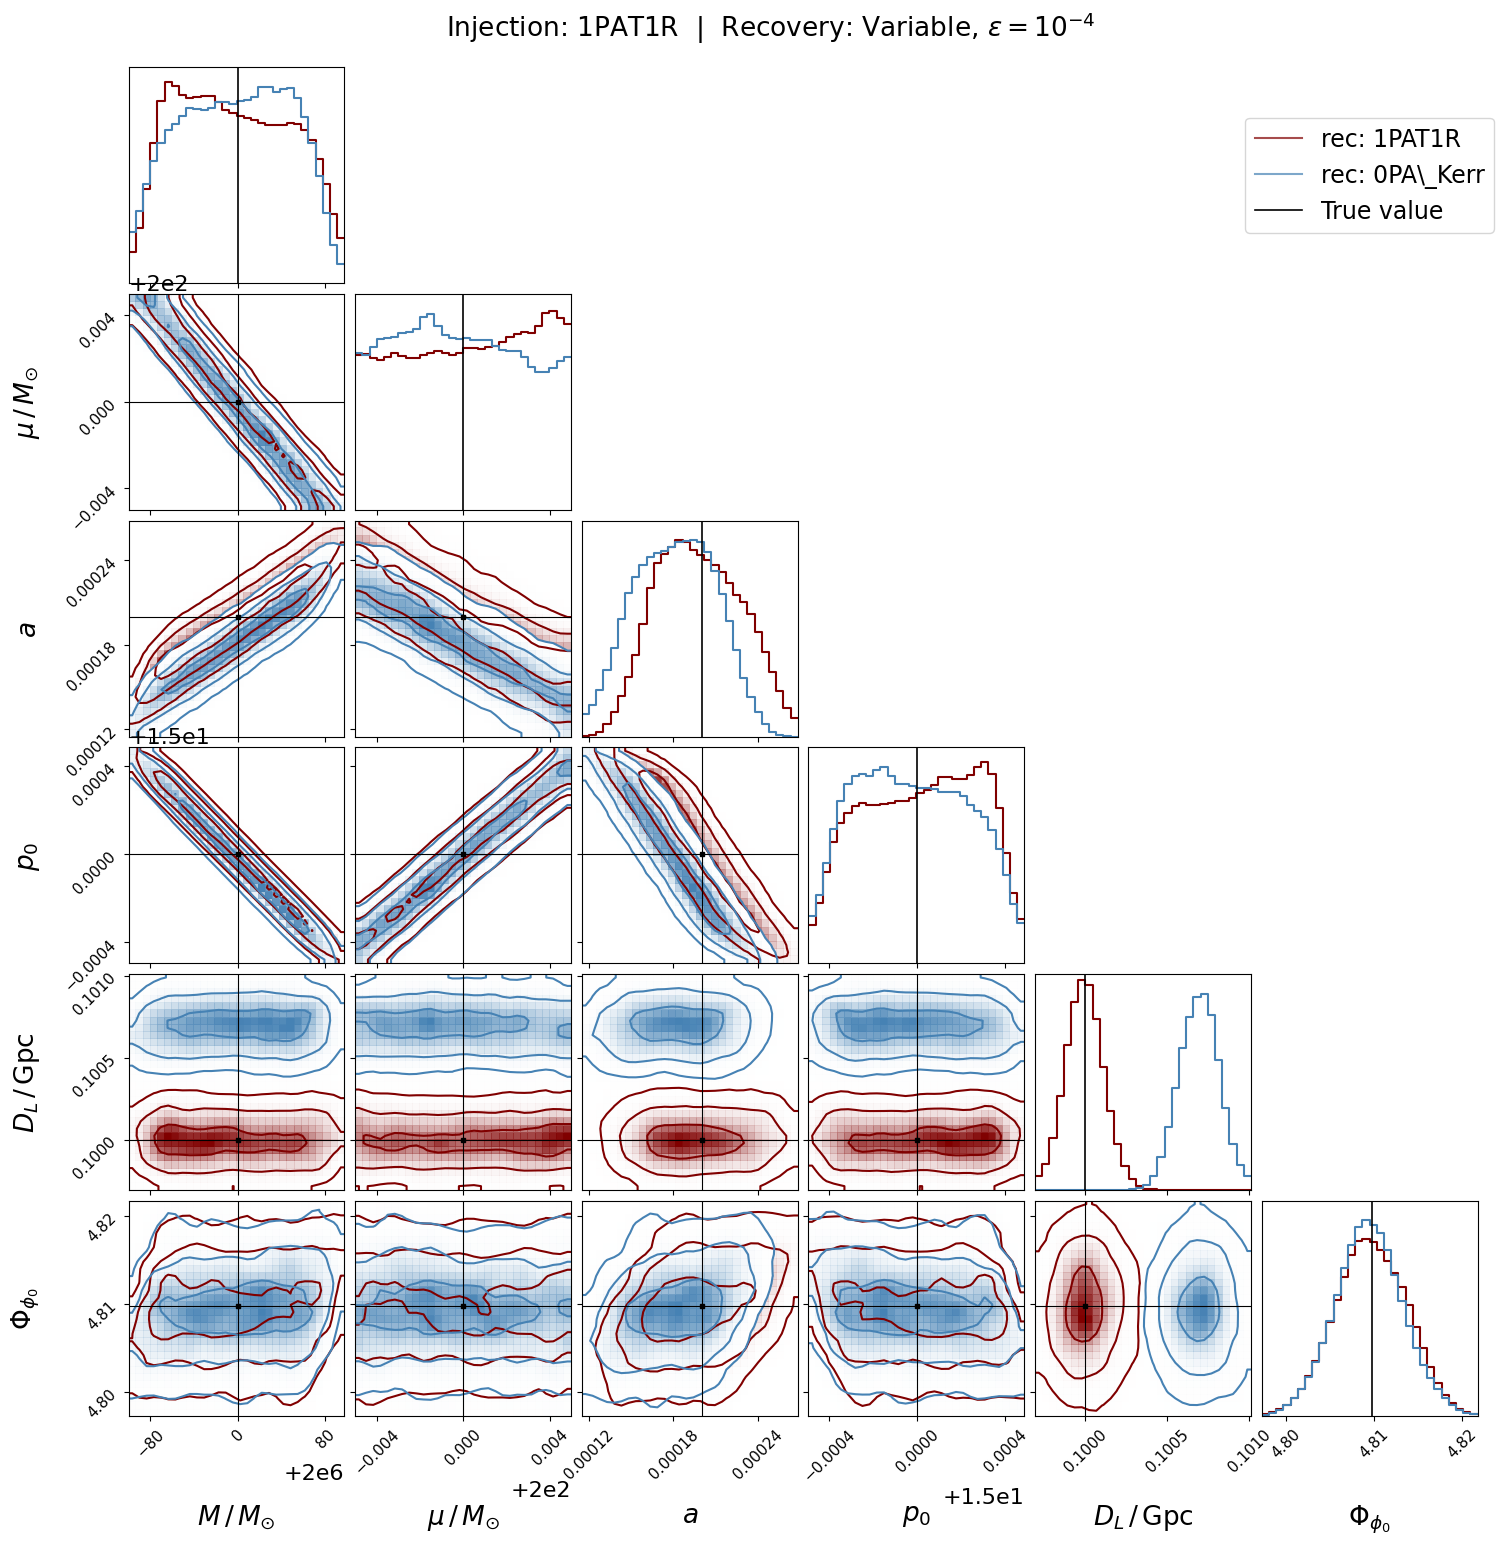

In [26]:
# samples_dict uses the named-dict format so corner_plot matches params by name.
# param_names_1PA is the reference (superset that includes chi2).
# corner_plot automatically intersects with 0PA's keys, so chi2 is excluded from
# the overlay and every remaining parameter lands on the correct axis.
samples_dict = {
    r'rec: 1PAT1R': {
        'color':   'maroon',
        'samples': named_1PA,
    },
    r'rec: 0PA\_Kerr': {
        'color':   'steelblue',
        'samples': named_0PA,
    },
}

plot_name_intrinsic = f'{os.getcwd()}/Comparison_eps{eps}_corner_intrinsic'

fig = corner_plot(
    samples_dict,
    true_vals_comparison,
    param_names_1PA,          # reference list (1PA superset); 0PA intersection drops chi2
    inj_model='1PAT1R',
    rec_model=r'Variable, $\epsilon = 10^{-4}$',
    exclude_sky=True,
    plot_name=plot_name_intrinsic,
)
plt.show()

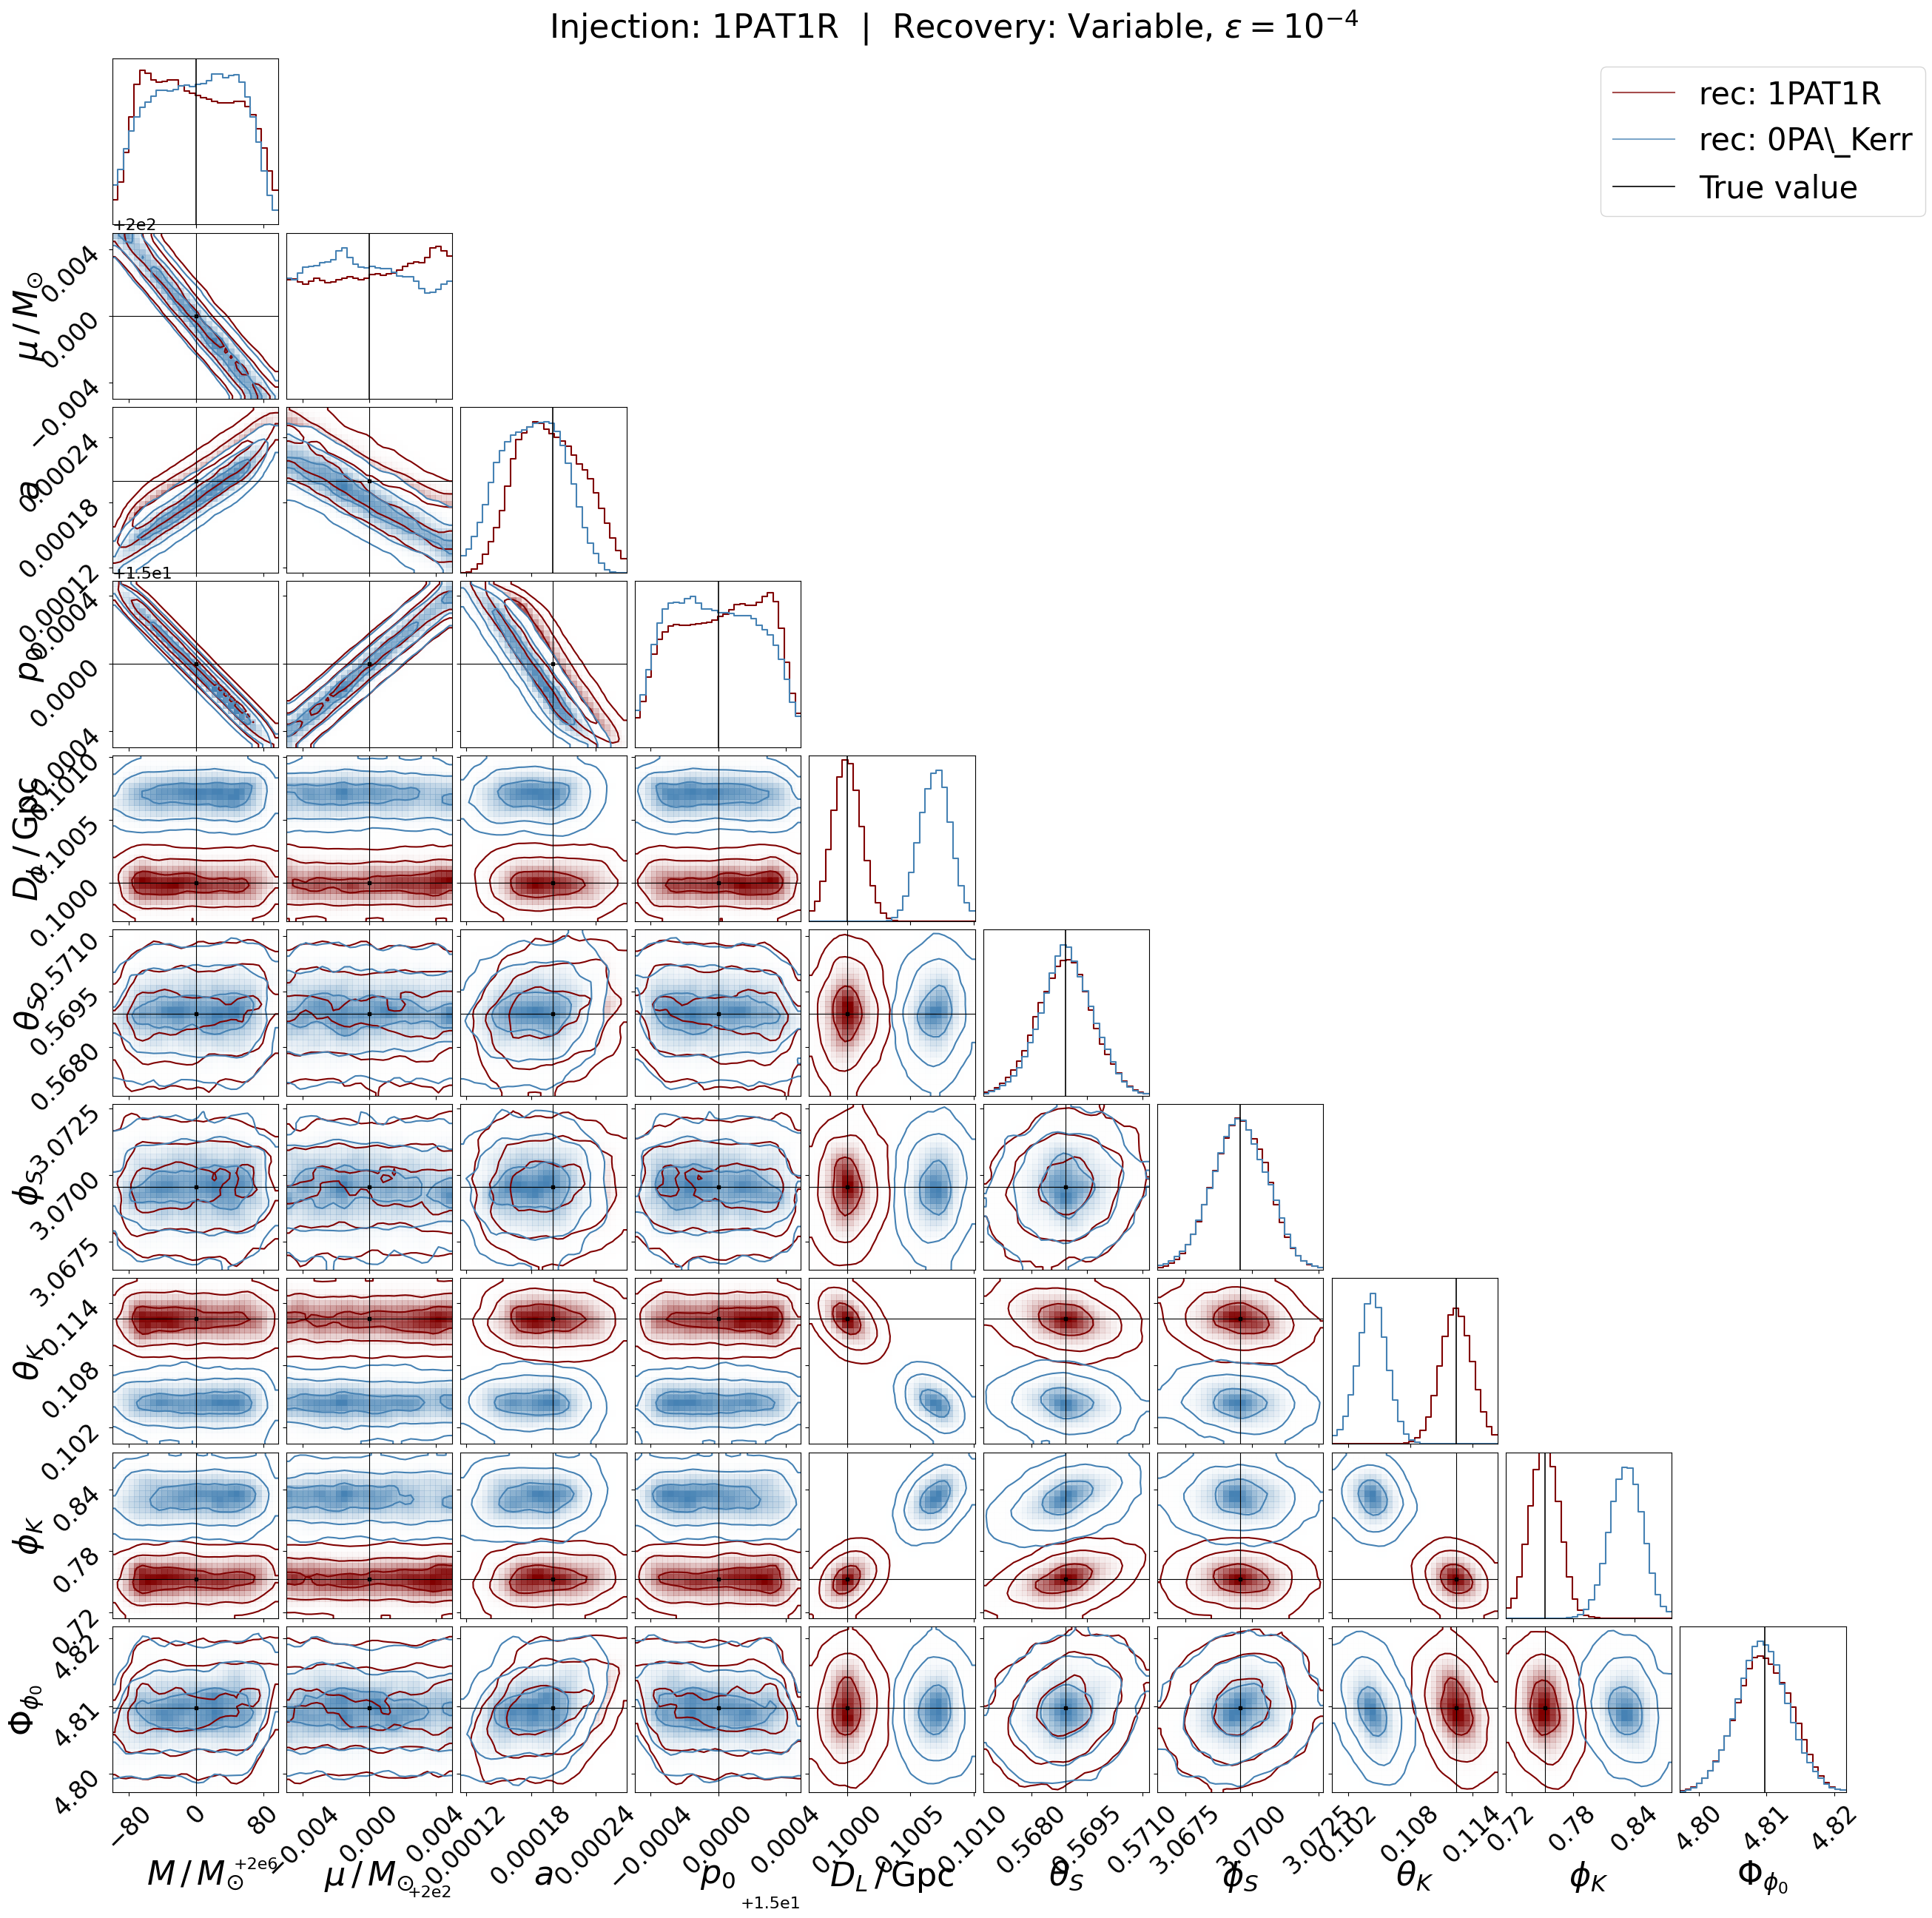

In [27]:
plot_name_intrinsic = f'{os.getcwd()}/Comparison_eps{eps}_corner_full'

fig = corner_plot(
    samples_dict,
    true_vals_comparison,
    param_names_1PA,          # reference list (1PA superset); 0PA intersection drops chi2
    inj_model='1PAT1R',
    rec_model=r'Variable, $\epsilon = 10^{-4}$',
    exclude_sky=False,
    plot_name=plot_name_intrinsic,
)
plt.show()

In [24]:
print(f'true_vals_comparison shape: {true_vals_comparison.shape}  (param_names_1PA, {len(param_names_1PA)} params)')
print(f'Intersection plotted: {[n for n in param_names_1PA if n in set(param_names_0PA)]}')

true_vals_comparison shape: (11,)  (param_names_1PA, 11 params)
Intersection plotted: ['M', 'mu', 'a', 'p0', 'd_L', 'theta_S', 'phi_S', 'theta_K', 'phi_K', 'Phi_phi0']
